In [1]:
# ======================================
# IMPORT LIBRARIES
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
# ======================================
# LOAD DATASET
# ======================================

df = pd.read_csv("../dataset/loan_approval_dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# ======================================
# DATASET SHAPE
# ======================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 614
Columns: 13


In [4]:
# ======================================
# DATASET INFO
# ======================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
# ======================================
# DESCRIPTIVE STATISTICS
# ======================================

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
# ======================================
# MISSING VALUES
# ======================================

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
# ======================================
# HANDLE MISSING VALUES
# ======================================
# Numeric columns: fill missing values with the median
# Categorical columns: fill missing values with the mode (most frequent value)
# Median/mode are used instead of mean to avoid distortion from outliers

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

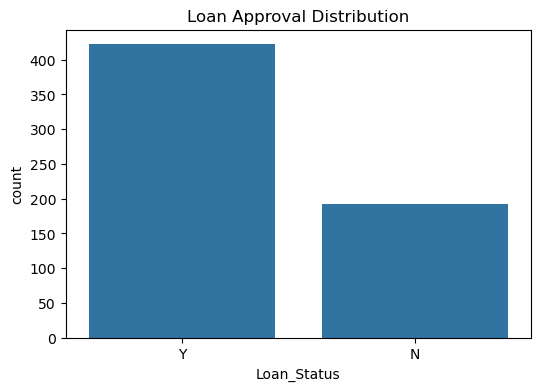

In [8]:
# ======================================
# EDA - LOAN APPROVAL DISTRIBUTION
# ======================================

plt.figure(figsize=(6, 4))
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

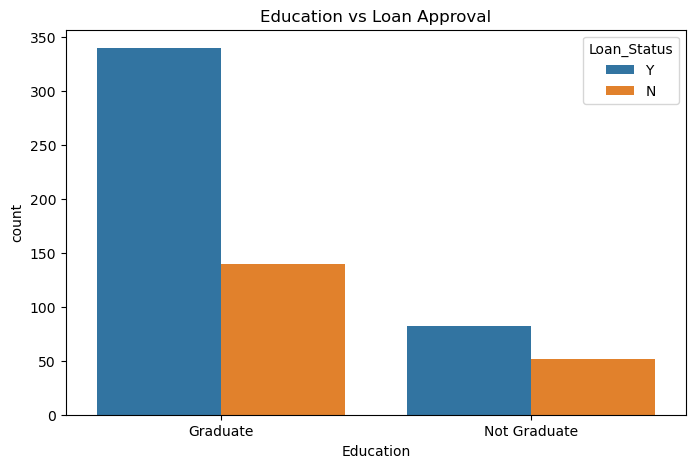

In [9]:
# ======================================
# EDA - EDUCATION vs LOAN STATUS
# ======================================

plt.figure(figsize=(8, 5))
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education vs Loan Approval")
plt.show()

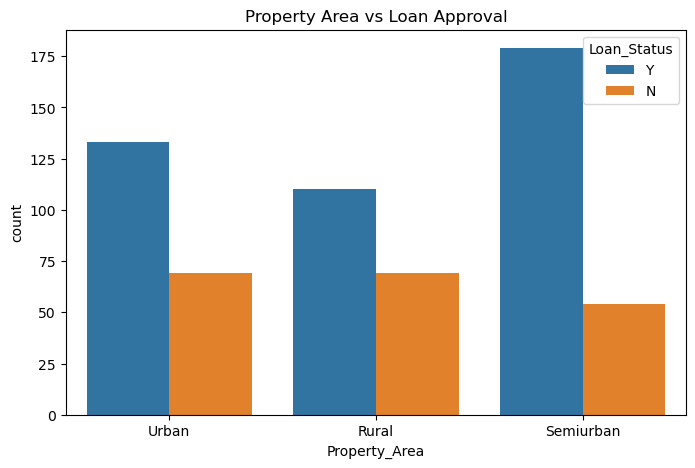

In [10]:
# ======================================
# EDA - PROPERTY AREA vs LOAN STATUS
# ======================================

plt.figure(figsize=(8, 5))
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

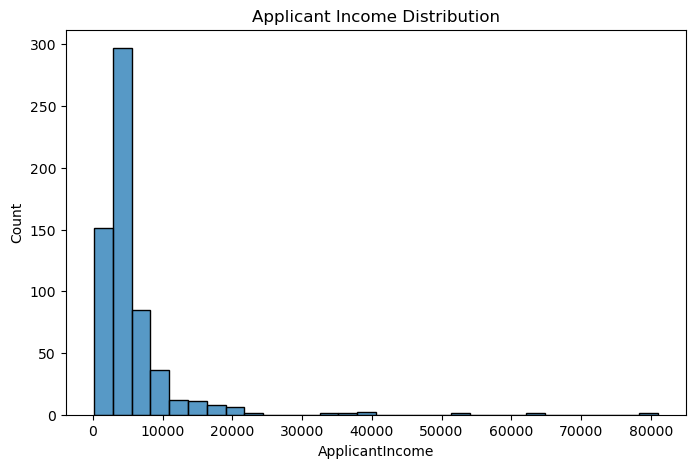

In [11]:
# ======================================
# EDA - APPLICANT INCOME DISTRIBUTION
# ======================================

plt.figure(figsize=(8, 5))
sns.histplot(df["ApplicantIncome"], bins=30)
plt.title("Applicant Income Distribution")
plt.show()

In [12]:
# ======================================
# LABEL ENCODING
# ======================================
# Convert categorical text columns into numeric codes so models can use them

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [13]:
# ======================================
# FEATURE ENGINEERING
# ======================================
# Combine ApplicantIncome and CoapplicantIncome into a single TotalIncome
# feature, since loan approval realistically depends on combined household
# income, not just the applicant's income alone

df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


In [14]:
# ======================================
# FEATURES AND TARGET
# ======================================

X = df.drop(["Loan_ID", "Loan_Status"], axis=1)
y = df["Loan_Status"]

print(X.columns.tolist())

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome']


In [15]:
# ======================================
# FEATURE SELECTION
# ======================================
# Use chi-square test to score how strongly each feature relates to the target

selector = SelectKBest(score_func=chi2, k=8)
selector.fit(abs(X), y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores = scores.sort_values(by="Score", ascending=False)
scores

,Feature,Score
6,CoapplicantIncome,11342.041603
11,TotalIncome,3559.550362
5,ApplicantIncome,93.904964
7,LoanAmount,32.821655
9,Credit_History,26.005877
8,Loan_Amount_Term,3.778554
3,Education,3.540502
1,Married,1.782425
10,Property_Area,0.377837
2,Dependents,0.085953


In [16]:
# ======================================
# APPLY FEATURE SELECTION
# ======================================
# Keep only the top 8 highest-scoring features identified above.
# This reduces noise/redundant features while keeping the strongest
# predictors (e.g. Credit_History, TotalIncome) for training

top_features = scores.head(8)["Feature"].tolist()
print("Selected Top Features:", top_features)

X = X[top_features]

Selected Top Features: ['CoapplicantIncome', 'TotalIncome', 'ApplicantIncome', 'LoanAmount', 'Credit_History', 'Loan_Amount_Term', 'Education', 'Married']


In [17]:
# ======================================
# SCALING
# ======================================
# Standardize features to mean 0, std 1 - required for distance-based
# models like KNN, and generally good practice for most models

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# ======================================
# TRAIN/TEST SPLIT
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# ======================================
# MODEL 1 - LOGISTIC REGRESSION (Basic Model)
# ======================================

lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
prec_lr = precision_score(y_test, pred_lr)
rec_lr = recall_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr)

print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1 Score:", f1_lr)

Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131


In [20]:
# ======================================
# MODEL 2 - KNN (Distance-Based Model)
# ======================================

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)
prec_knn = precision_score(y_test, pred_knn)
rec_knn = recall_score(y_test, pred_knn)
f1_knn = f1_score(y_test, pred_knn)

print("Accuracy:", acc_knn)
print("Precision:", prec_knn)
print("Recall:", rec_knn)
print("F1 Score:", f1_knn)

Accuracy: 0.8048780487804879
Precision: 0.7745098039215687
Recall: 0.9875
F1 Score: 0.8681318681318682


In [21]:
# ======================================
# MODEL 3 - RANDOM FOREST (Ensemble Model)
# ======================================

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
prec_rf = precision_score(y_test, pred_rf)
rec_rf = recall_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)

print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1 Score:", f1_rf)

Accuracy: 0.7642276422764228
Precision: 0.7628865979381443
Recall: 0.925
F1 Score: 0.8361581920903954


In [22]:
# ======================================
# HYPERPARAMETER TUNING - KNN
# ======================================

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 11}
Best CV Score: 0.8023706452277881


In [23]:
# ======================================
# HYPERPARAMETER TUNING - RANDOM FOREST
# ======================================
# Random Forest is the model we deploy, so it is the one we tune carefully

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

# Replace the untuned model with the tuned best version
rf = rf_grid.best_estimator_
pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
prec_rf = precision_score(y_test, pred_rf)
rec_rf = recall_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)

print("\nTuned Random Forest Performance:")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1 Score:", f1_rf)

Best Parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.8125128839414554

Tuned Random Forest Performance:
Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131


In [24]:
# ======================================
# CLASSIFICATION REPORT - RANDOM FOREST
# ======================================

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



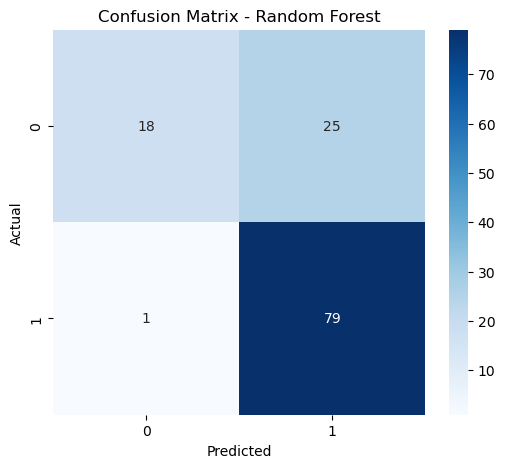

In [25]:
# ======================================
# CONFUSION MATRIX - RANDOM FOREST
# ======================================

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
# ======================================
# MODEL COMPARISON
# ======================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "Accuracy": [acc_lr, acc_knn, acc_rf],
    "Precision": [prec_lr, prec_knn, prec_rf],
    "Recall": [rec_lr, rec_knn, rec_rf],
    "F1 Score": [f1_lr, f1_knn, f1_rf]
})

results = results.sort_values(by="Accuracy", ascending=False)
results

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.804878,0.774510,0.9875,0.868132
0,Logistic Regression,0.788618,0.759615,0.9875,0.858696
2,Random Forest,0.788618,0.759615,0.9875,0.858696


In [27]:
# ======================================
# BEST MODEL
# ======================================

best_model_row = results.loc[results["Accuracy"].idxmax()]
print(best_model_row)

Model             KNN
Accuracy     0.804878
Precision     0.77451
Recall         0.9875
F1 Score     0.868132
Name: 1, dtype: object


In [28]:
# ======================================
# FEATURE IMPORTANCE - RANDOM FOREST
# ======================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
4,Credit_History,0.498572
1,TotalIncome,0.146758
2,ApplicantIncome,0.090688
3,LoanAmount,0.081108
0,CoapplicantIncome,0.077178
5,Loan_Amount_Term,0.066778
7,Married,0.021486
6,Education,0.017432


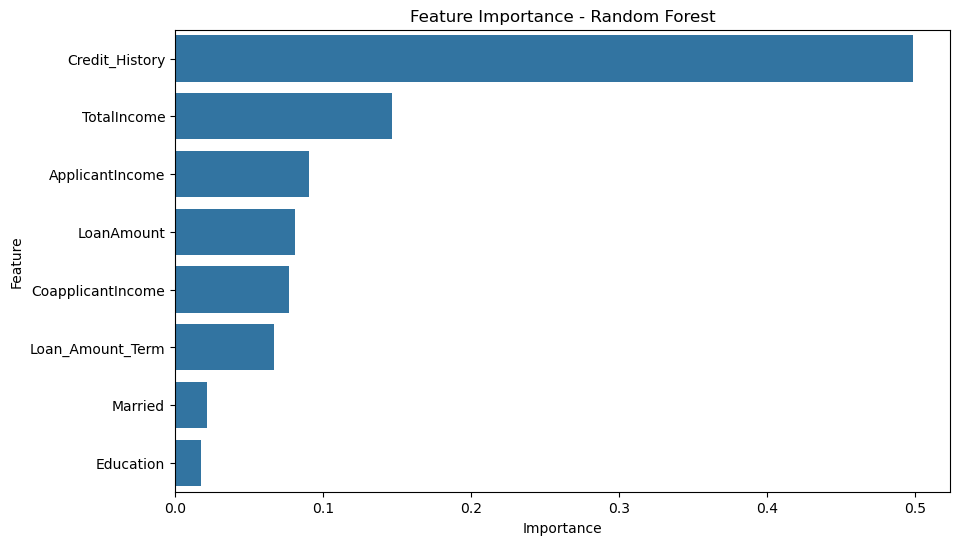

In [29]:
# ======================================
# FEATURE IMPORTANCE PLOT
# ======================================

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

In [30]:
# ======================================
# FINAL FEATURE COUNT
# ======================================

print("Number of Features Used:", len(X.columns))
print(X.columns.tolist())

Number of Features Used: 8
['CoapplicantIncome', 'TotalIncome', 'ApplicantIncome', 'LoanAmount', 'Credit_History', 'Loan_Amount_Term', 'Education', 'Married']


In [31]:
# ======================================
# SAVE MODEL AND SCALER
# ======================================

joblib.dump(rf, "../deployment/model.pkl")
joblib.dump(scaler, "../deployment/scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
